# 06 - Model Evaluation, Error Analysis & Visualization

Notebook này tập trung vào đánh giá chuyên sâu mô hình RL dựa trên các luật chơi mới:
- **Adjacency:** Sai lệch tối đa 1 lớp.
- **Binary Precision:** Phân tách tuyệt đối giữa Kẹt và Không kẹt.
- **Class Balance:** Đánh giá độ công bằng giữa 6 lớp.

In [1]:
import os
import sys
from pathlib import Path

# Add project root to sys.path
cwd = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in [cwd] + list(cwd.parents) if (p / 'src').exists()), cwd)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

from src.rl.artifacts import get_rl_evaluation_predictions_path
from src.rl.evaluation import compute_ops_metrics

In [2]:
# ==== Input config ====
RUN_ID = os.getenv('RL_RUN_ID', 'notebook_warmstart_h15')
MODE = os.getenv('RL_MODE', 'warmstart')

PREDICTIONS_PATH = get_rl_evaluation_predictions_path(mode=MODE, run_id=RUN_ID)

assert PREDICTIONS_PATH.exists(), f'Không tìm thấy file kết quả: {PREDICTIONS_PATH}'

eval_df = pd.read_parquet(PREDICTIONS_PATH)
y_true = eval_df['y_true'].to_numpy()
y_pred = eval_df['y_pred'].to_numpy()

print(f"Nạp dữ liệu thành công từ: {PREDICTIONS_PATH}")
print(f"Tổng số mẫu đánh giá: {len(eval_df)}")

Nạp dữ liệu thành công từ: /app/artifacts/rl/evaluation/predictions_warmstart_notebook_warmstart_h15.parquet
Tổng số mẫu đánh giá: 152859


## 1. Visualization: Confusion Matrix & Adjacency Analysis

Mục tiêu: Các điểm sáng tập trung tại đường chéo và các ô lân cận (Adjacency).

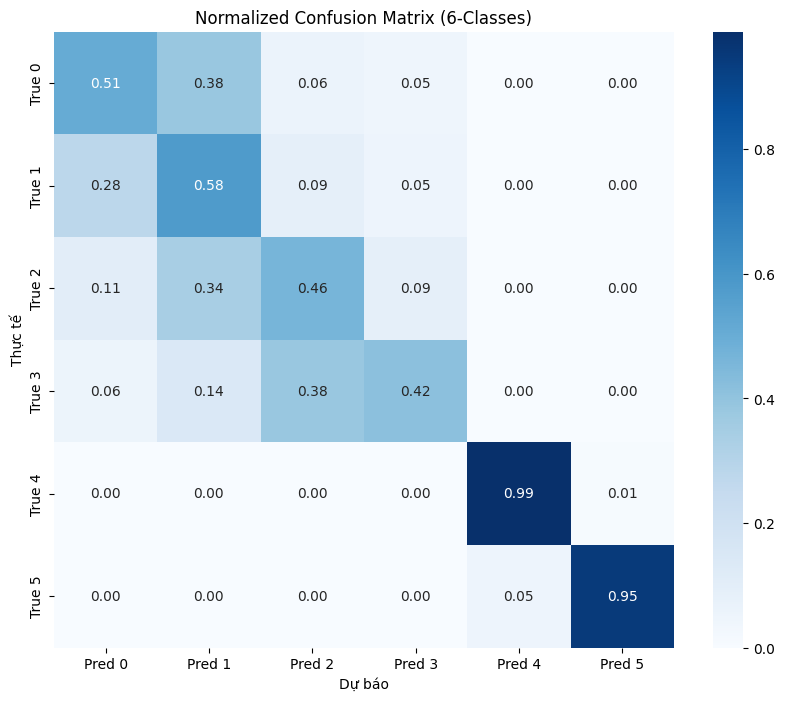

In [3]:
cm = confusion_matrix(y_true, y_pred, labels=range(6), normalize='true')

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', 
            xticklabels=[f'Pred {i}' for i in range(6)], 
            yticklabels=[f'True {i}' for i in range(6)])
plt.title('Normalized Confusion Matrix (6-Classes)')
plt.xlabel('Dự báo')
plt.ylabel('Thực tế')
plt.show()

/tmp/ipykernel_58234/2274807548.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=error_pct.index, y=error_pct.values, palette='viridis')


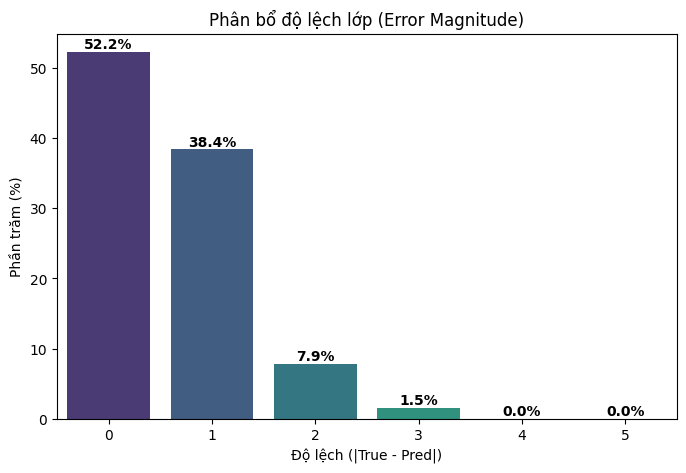

Tỉ lệ tuân thủ luật Adjacency (Lệch <= 1 lớp): 90.60%


In [4]:
diffs = np.abs(y_true - y_pred)
error_counts = pd.Series(diffs).value_counts().sort_index()
error_pct = error_counts / len(diffs) * 100

plt.figure(figsize=(8, 5))
sns.barplot(x=error_pct.index, y=error_pct.values, palette='viridis')
plt.title('Phân bổ độ lệch lớp (Error Magnitude)')
plt.xlabel('Độ lệch (|True - Pred|)')
plt.ylabel('Phần trăm (%)')
for i, val in enumerate(error_pct.values):
    plt.text(i, val + 0.5, f'{val:.1f}%', ha='center', fontweight='bold')
plt.show()

print(f"Tỉ lệ tuân thủ luật Adjacency (Lệch <= 1 lớp): {error_pct.get(0, 0) + error_pct.get(1, 0):.2f}%")

## 2. Binary Analysis: Congested vs Non-Congested

Nhóm: {0,1,2} -> 0 (Thông thoáng), {3,4,5} -> 1 (Kẹt xe).

Binary Classification Report ({0,1,2} vs {3,4,5}):
              precision    recall  f1-score   support

 Thanh thoát       0.93      0.94      0.93    132124
      Kẹt xe       0.58      0.56      0.57     20735

    accuracy                           0.88    152859
   macro avg       0.75      0.75      0.75    152859
weighted avg       0.88      0.88      0.88    152859



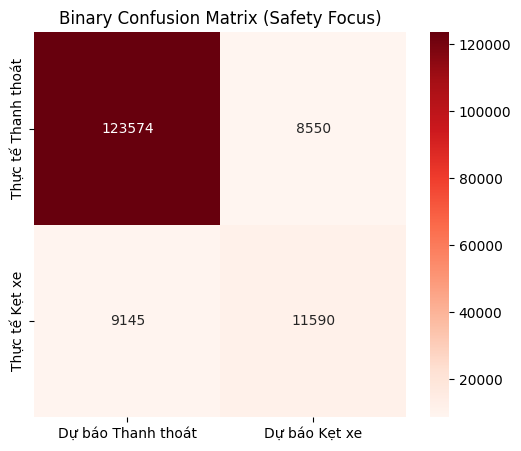

🚩 Miss Rate (Bỏ lỡ kẹt xe - CẦN GIẢM): 44.10%
⚠️ False Alarm Rate (Báo nhầm - CHẤP NHẬN ĐƯỢC): 6.47%


In [5]:
y_true_bin = (y_true >= 3).astype(int)
y_pred_bin = (y_pred >= 3).astype(int)

print('Binary Classification Report ({0,1,2} vs {3,4,5}):')
print(classification_report(y_true_bin, y_pred_bin, target_names=['Thanh thoát', 'Kẹt xe']))

cm_bin = confusion_matrix(y_true_bin, y_pred_bin)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Dự báo Thanh thoát', 'Dự báo Kẹt xe'], 
            yticklabels=['Thực tế Thanh thoát', 'Thực tế Kẹt xe'])
plt.title('Binary Confusion Matrix (Safety Focus)')
plt.show()

tn, fp, fn, tp = cm_bin.ravel()
miss_rate = fn / (fn + tp) if (fn + tp) > 0 else 0
false_alarm = fp / (fp + tn) if (fp + tn) > 0 else 0

print(f"🚩 Miss Rate (Bỏ lỡ kẹt xe - CẦN GIẢM): {miss_rate:.2%}")
print(f"⚠️ False Alarm Rate (Báo nhầm - CHẤP NHẬN ĐƯỢC): {false_alarm:.2%}")

## 3. Class Balance: 6-Class Recognition Equality

Đánh giá xem 6 lớp có được nhận diện đồng đều không (Macro F1).

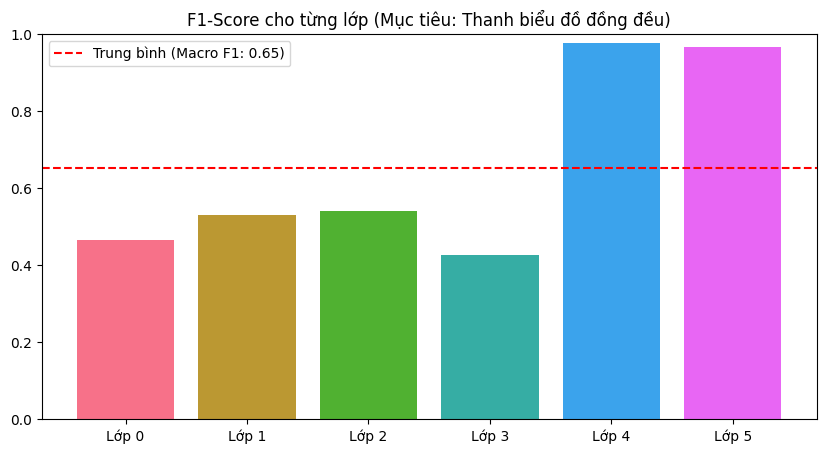

In [6]:
report = classification_report(y_true, y_pred, output_dict=True, labels=range(6), zero_division=0)
f1_scores = [report[str(i)]['f1-score'] for i in range(6)]

plt.figure(figsize=(10, 5))
plt.bar([f'Lớp {i}' for i in range(6)], f1_scores, color=sns.color_palette('husl', 6))
plt.axhline(np.mean(f1_scores), color='red', linestyle='--', label=f'Trung bình (Macro F1: {np.mean(f1_scores):.2f})')
plt.title('F1-Score cho từng lớp (Mục tiêu: Thanh biểu đồ đồng đều)')
plt.ylim(0, 1.0)
plt.legend()
plt.show()